In [3]:
%matplotlib inline

import sklearn.metrics
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import io
import glob
import scipy.misc
import numpy as np
import pandas as pd
from six import BytesIO
from PIL import Image, ImageDraw, ImageFont
import shutil
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import layers
from tensorflow.keras import Model
import matplotlib
from tensorflow.keras.optimizers import RMSprop
import os
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.image as mpimg
from matplotlib.ticker import FormatStrFormatter
from tensorflow.keras.utils import plot_model


LEARNING_RATE = 0.0001
repo_url = 'https://github.com/adleberg/medical-ai'
IMAGE_HEIGHT, IMAGE_WIDTH = 299, 299

def load_image_into_numpy_array(image):
    image = image.convert('RGB')
    (im_width, im_height) = image.size
    return np.array(image.getdata()).reshape(
        (im_height, im_width, 3)).astype(np.uint8)

print("Welcome! Downloading some things... this will take a minute.")

%cd -q /content
repo_dir_path = os.path.abspath(os.path.join('.', os.path.basename(repo_url)))
!git clone {repo_url} --quiet
%cd -q {repo_dir_path}
!git pull -q

!apt-get install graphviz -y
!pip install pydot

print("Great! You clicked on it correctly. Now let's get started.")

/tmp/ipykernel_1308/2035515162.py:10: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


Welcome! Downloading some things... this will take a minute.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-9ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Great! You clicked on it correctly. Now let's get started.


In [4]:
finding = "Cardiomegaly"
# finding = finding.capitalize()

In [5]:
df = pd.read_csv("/content/medical-ai/labels.csv")
df.head()

,filename,height,width,label,xmin,ymin,xmax,ymax,view
0,00013118_008.jpg,2992,2991,Atelectasis,225.0,547.0,311.0,626.0,PA
1,00014716_007.jpg,3056,2544,Atelectasis,686.0,131.0,871.0,444.0,AP
2,00029817_009.jpg,3056,2544,Atelectasis,221.0,317.0,376.0,533.0,AP
3,00014687_001.jpg,2500,2048,Atelectasis,726.0,494.0,867.0,549.0,AP
4,00017877_001.jpg,2500,2048,Atelectasis,660.0,569.0,860.0,647.0,AP


In [6]:
positives = df.loc[df["label"] == finding]
negatives = df.loc[df["label"] == "No Finding"]
n = len(positives)

n

146

In [7]:
TRAIN_RATIO = 0.8
TEST_RATIO = 0.2
TRAIN_N = int(n*TRAIN_RATIO)
TEST_N = int(n*TEST_RATIO)
print(TRAIN_N,TEST_N)

116 29


In [8]:
len(negatives)

980

In [ ]:
positives[:TRAIN_N]

,filename,height,width,label,xmin,ymin,xmax,ymax,view
161,00005066_030.jpg,2500,2048,Cardiomegaly,277.0,459.0,817.0,760.0,AP
162,00009608_024.jpg,2500,2048,Cardiomegaly,394.0,402.0,759.0,743.0,AP
163,00000661_000.jpg,2021,2021,Cardiomegaly,298.0,437.0,846.0,865.0,PA
164,00019018_007.jpg,3056,2544,Cardiomegaly,366.0,520.0,809.0,787.0,AP
165,00000211_041.jpg,2500,2048,Cardiomegaly,224.0,416.0,736.0,846.0,AP
...,...,...,...,...,...,...,...,...,...
272,00002059_008.jpg,2500,2048,Cardiomegaly,374.0,465.0,928.0,829.0,AP
273,00020438_011.jpg,3056,2544,Cardiomegaly,329.0,360.0,815.0,840.0,AP
274,00014574_000.jpg,2992,2991,Cardiomegaly,369.0,365.0,806.0,760.0,PA
275,00012793_000.jpg,2834,2991,Cardiomegaly,353.0,378.0,847.0,782.0,PA


In [ ]:
negatives[:TRAIN_N]

,filename,height,width,label,xmin,ymin,xmax,ymax,view
984,00000002_000.jpg,2500,2048,No Finding,NaN,NaN,NaN,NaN,PA
985,00000005_000.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA
986,00000005_001.jpg,2500,2048,No Finding,NaN,NaN,NaN,NaN,AP
987,00000005_002.jpg,2500,2048,No Finding,NaN,NaN,NaN,NaN,AP
988,00000005_003.jpg,2992,2991,No Finding,NaN,NaN,NaN,NaN,PA
...,...,...,...,...,...,...,...,...,...
1095,00000070_000.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA
1096,00000071_003.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA
1097,00000073_000.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA
1098,00000073_001.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA


In [ ]:
len(positives),len(negatives),n,TRAIN_N,TEST_N

(146, 980, 146, 116, 29)

In [9]:
train_labels = pd.concat([positives[:TRAIN_N],negatives[:TRAIN_N]])
test_labels = pd.concat([positives[TRAIN_N:],negatives[TRAIN_N:n]])

In [ ]:
len(train_labels),len(test_labels)

(232, 60)

In [ ]:
train_labels

,filename,height,width,label,xmin,ymin,xmax,ymax,view
161,00005066_030.jpg,2500,2048,Cardiomegaly,277.0,459.0,817.0,760.0,AP
162,00009608_024.jpg,2500,2048,Cardiomegaly,394.0,402.0,759.0,743.0,AP
163,00000661_000.jpg,2021,2021,Cardiomegaly,298.0,437.0,846.0,865.0,PA
164,00019018_007.jpg,3056,2544,Cardiomegaly,366.0,520.0,809.0,787.0,AP
165,00000211_041.jpg,2500,2048,Cardiomegaly,224.0,416.0,736.0,846.0,AP
...,...,...,...,...,...,...,...,...,...
1095,00000070_000.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA
1096,00000071_003.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA
1097,00000073_000.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA
1098,00000073_001.jpg,2048,2500,No Finding,NaN,NaN,NaN,NaN,PA


## 2. Preparing the Data

Now, we've figured out what we want our model to take a look at. Behind the scenes, we just need to sort the data into two folders: one with **negative** cases and one with **positive** cases.

In [10]:
rootdir = "/content/medical-ai/images/"
os.makedirs(rootdir + finding + "/test/positive",exist_ok=True)
os.makedirs(rootdir + finding + "/train/positive",exist_ok=True)
os.makedirs(rootdir + finding + "/test/negative",exist_ok=True)
os.makedirs(rootdir + finding + "/train/negative",exist_ok=True)

In [11]:
for idx,image in positives[:TRAIN_N].iterrows():
  source = rootdir + image["filename"]
  dst = rootdir + finding + "/train/positive/" + image["filename"]
  shutil.copy(source,dst)

for idx,image in positives[TRAIN_N:].iterrows():
  source = rootdir + image["filename"]
  dst = rootdir + finding + "/test/positive/" + image["filename"]
  shutil.copy(source,dst)

for idx,image in negatives[:TRAIN_N].iterrows():
  source = rootdir + image["filename"]
  dst = rootdir + finding + "/train/negative/" + image["filename"]
  shutil.copy(source,dst)

for idx,image in negatives[TRAIN_N:n].iterrows():
  source = rootdir + image["filename"]
  dst = rootdir + finding + "/test/negative/" + image["filename"]
  shutil.copy(source,dst)


In [12]:
from PIL import Image, ImageDraw, ImageFont

# load images into memory for visualization
positive_imgs, negative_imgs = [], []
IMAGE_HEIGHT, IMAGE_WIDTH = 299, 299

for idx, row in positives[:6].iterrows():
  image_path = rootdir+row["filename"]
  image = Image.open(image_path).resize((IMAGE_WIDTH, IMAGE_HEIGHT))
  positive_imgs.append(load_image_into_numpy_array(image))

for idx, row in negatives[:6].iterrows():
  image_path = rootdir+row["filename"]
  image = Image.open(image_path).resize((IMAGE_WIDTH, IMAGE_HEIGHT))
  negative_imgs.append(load_image_into_numpy_array(image))

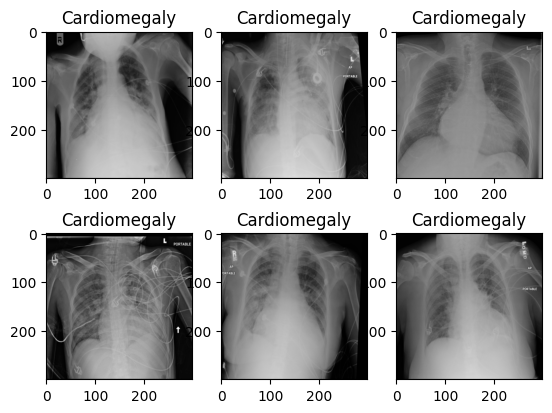

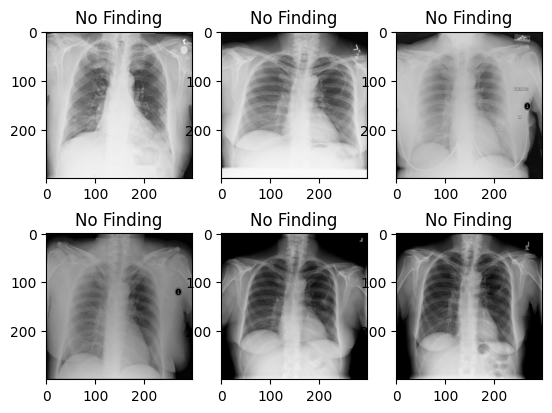

In [13]:
for idx, img in enumerate(positive_imgs[:6]):
  plt.subplot(2,3,idx+1)#2 roww and 3 columns and plot's position within the grid
  plt.title(finding)
  plt.imshow(positive_imgs[idx])
plt.show()

for idx, img in enumerate(negative_imgs[:6]):
  plt.subplot(2,3,idx+1)
  plt.title("No Finding")
  plt.imshow(negative_imgs[idx])
plt.show()

## train the model



we will be using a technology called InceptionV3 to look at our images. this is a model that google created to do image analysis, and has released to the general public.It's pretty smart lets see how smart it is on our images.

one thind that is commonly done in computer vision is tjo taske a model trained on a very large dataset,run it on our own,smaller dataset, and extract the intermediate representations (features) that the model generates. these representations are frequently informative for your own coumputer vision task, even though the task may be quite different from the problem that the original model was trained on. This partiular model was trained on imageNet a large deataset of web images(1.4M images and 1000 classes)
> Add blockquote




In [14]:
pre_trained_model = InceptionV3(input_shape=(IMAGE_HEIGHT,IMAGE_WIDTH,3), weights="imagenet",include_top=False)

for layer in pre_trained_model.layers:
  layer.trainable= False

last_layer = pre_trained_model.get_layer("mixed7")
last_output = last_layer.output

x = layers.Flatten()(last_output)
x = layers.Dense(1024, activation = 'relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(1, activation = 'sigmoid')(x)

model = Model(pre_trained_model.input,x)
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['acc'])




87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


###Define the Base Model
We use the InceptionV3 model pre-trained on the ImageNet dataset as our base model.

In [15]:
base_dir = rootdir
train_dir = os.path.join(base_dir,finding,"train")
test_dir = os.path.join(base_dir,finding,"test")

train_pos_dir = os.path.join(train_dir,'positive')
train_nag_dir = os.path.join(train_dir,'negative')

test_pos_dir = os.path.join(test_dir,'positive')
test_nag_dir = os.path.join(test_dir,'negative')

In [16]:
train_datagen = ImageDataGenerator(
    rescale= 1./255,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = False,


)
val_datagen = ImageDataGenerator(rescale= 1./255)


In [17]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size = 1,
    class_mode = 'binary'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size = 1,
    class_mode = 'binary'
)

train_step= len(os.listdir(train_pos_dir)) + 2
test_step = len(os.listdir(test_pos_dir)) + 2

Found 232 images belonging to 2 classes.
Found 60 images belonging to 2 classes.


## Run Model

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch = train_step,
    epochs = 20,
    validation_data = test_generator,
    validation_steps = test_step,
    verbose = 2
)

Epoch 1/20
118/118 - 530s - 4s/step - acc: 0.6356 - loss: 18.3301 - val_acc: 0.6562 - val_loss: 7.7679
Epoch 2/20


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


118/118 - 449s - 4s/step - acc: 0.5614 - loss: 16.2882 - val_acc: 0.5000 - val_loss: 7.3362
Epoch 3/20
118/118 - 502s - 4s/step - acc: 0.6271 - loss: 8.9370 - val_acc: 0.5625 - val_loss: 5.7321
Epoch 4/20
118/118 - 502s - 4s/step - acc: 0.6754 - loss: 5.1986 - val_acc: 0.5312 - val_loss: 7.2106
Epoch 5/20
118/118 - 501s - 4s/step - acc: 0.6102 - loss: 3.8235 - val_acc: 0.6250 - val_loss: 1.6317
Epoch 6/20
118/118 - 446s - 4s/step - acc: 0.6842 - loss: 1.4697 - val_acc: 0.6562 - val_loss: 1.3541
Epoch 7/20
118/118 - 514s - 4s/step - acc: 0.6441 - loss: 1.3103 - val_acc: 0.7812 - val_loss: 0.4729
Epoch 8/20


lets plot the training and test loss and accuracy to show it conclusively

In [1]:
acc = history.history['acc']
val_acc = history.history['val_acc']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.subplot(2,1,1)
plt.plot(epochs, acc, label="train")
plt.plot(epochs, val_acc, label="test")
plt.title("training and testing accuracy")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")

plt.subplot(2,1,2)
plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="test")
plt.title("training and testing loss")
plt.xlabel("Epochs(loss)")
plt.legend(loc="lower right")

NameError: name 'history' is not defined

## Evaluating performance

In [2]:
def predict_image(filename):
  image = Image.open(filename).resize((IMAGE_HEIGHT,IMAGE_WIDTH))
  image_np = load_image_into_numpy_array(image)
  exp = np.true_divide(image_np,255.0)
  exp = np.stack((exp,)*3, axis =-1)
  expanded = np.expand_dims(exp, axis=0)
  return model.predict(expanded)[0][0]

def show_df_row(row):
  image_path = row['filepath']
  image = Image.open(filename).resize((IMAGE_HEIGHT,IMAGE_WIDTH))
  image_np = load_image_into_numpy_array(image)
  exp = np.true_divide(image_np,255.0)
  exp = np.stack((exp,)*3, axis =-1)
  expanded = np.expand_dims(exp, axis=0)
  pred = model.predict(expanded)[0][0]
  guess = "neg"
  if pred > 0.5 : guess = "pos"
  title = "Image: " + row["filename"]+" Label: "+row["label"]+" Guess: "+guess+" Score: "+str(pred)
  plt.title(title)
  plt.imshow(img)
  plt.show()
  return


In [ ]:
results = []
for image in os.listdir(test_neg_dir):
  filename = test_neg_dir+"/"+image
  confidence = predict__image(filename)
  guess= 'pos' if confidence >0.5 else 'neg'
  results.append([filename,image,"neg",guess,confidence])

for image in os.listdir(test_pos_dir):
  filename = test_pos_dir+"/"+image
  confidence = predict_image(filename)
  guess= 'pos' if confidence >0.5 else 'neg'
  results.append([filename,image,"pos",guess,confidence])

sorted_results = sorted(results, key= lambda x:x[4], reverse = True)
df = pd.DataFrame(data=sorted_results,columns=["filepath","filename","label","guess","confidence"])




In [ ]:
df.head()

In [ ]:
n = random.randint(0, len(df)-1)
show_df_row(df.iloc[n])

In [ ]:
df[::5]['filename','label',"guess","confidence"]

show histogram

In [ ]:
from matplotlib.ticker import FormatStrFormatter
pos = df.loc[df['lable'] == "pos"]["confidence"]
neg = df.loc[df['label'] == "neg"]["confidnece"]

fig, ax = plt.subplots()
n, bins, patches = plt.hist([pos,neg],np.arange(0.0,1.1,0.1).tolist(), \
                            edgecolor='black', linewidth = 0.5,density=False,histtype='bar',stacked=True, \
                            color=['green','red'],label=[finding,"No Finding"])
plt.xlabel('confidence')
plt.ylabel('N')
plt.xticks()
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.title('confidence scor for different images')
plt.legend(loc='lower right',fontsize=16)
plt.show()


create cutoff point

In [ ]:
def create_with_cutoff(cutoff):
  _, ax = plt.subplots()
  TP = df.loc[(df['label']=="pos") & (df['confidence'] > cutoff)]["confidence"]
  FP = df.loc[(df['label']=="neg") & (df['confidence'] > cutoff)]["confidence"]
  TN = df.loc[(df['label']=="neg") & (df['confidence'] < cutoff)]["confidence"]
  FN = df.loc[(df['label']=="pos") & (df['confidence'] < cutoff)]["confidence"]
  plt.hist([TP,FP,TN,FN],np.arange(0.0,1.1,0.1).tolist(), \
              edgecolor='black', linewidth = 0.5,density=False,histtype='bar',\
              stacked=True, color=['limegreen','forestgreen','orangered','salmon'],\
              label=['TP','FP','TN','FN'])
  plt.xlabel('confidence')
  plt.ylabel('N')
  plt.xticks(bins)
  ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
  plt.title('confidence scores for different images')
  plt.legend(loc='upper right',fontsize=16)
  plt.axvline(cutoff,color='k',linestyle='dashed',linewidth=2)

  sens = round(len(TP)/(len(TP)+len(FN)),2)
  spec = round(len(TN)/len(TN)+len(FP),2)

  stats = "sensitivity: " +str(sens)+"\n"+"specificity"+str(spec)+"\n\n""TP: "+str(len(TP))+"\n"+"FP: "+str(len(FP))
  plt.text(0.05,0.65,stats,fontsize=14, transform = ax.transAxes)
  plt.show()

create_with_cutoff(cutoff=0.5)

show ROC curve

In [ ]:
def create_auc_curve(classification):
  squares ={}
  for x in classifications:
    conf = x[4]
    TP, FP, TN, FN =0,0,0,0
    for row in classifications:
      assert (row[2] == "neg" or row[2] == "pos")
      if row[2] == "pos":
        if float(row[4]) < conf: TN += 1
        else: FP += 1

      else:
        if float(row[4]) > conf: TP += 1
        else: FN += 1

    squares[conf] = [TP,FP,TN,FN]
    sens_spec ={}

    for entry in squares:
      sens = squares = [entry][0] / float(squares[entry][0] + squares[entry][3])
      spec = squares[entry][2] / float(squares[entry][2] + squares[entry][1])
      sens_spec[entry] = (1-spec,sens)
      return squares,sens_spec

squares,sens_spec = create_auc_curve(sorted_results)

x = []
y = []
for point in sens_spec.keys():
  x.append(sens_spec[point][0])
  y.append(sens_spec[point][1])

auc =sklearn.metrics.auc(x,y)
lw = 2
plt.plot(x,y,color='darkorange',lw=lw,label='ROC curve (area = %0.3f)' % auc)
plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel('1-specificity')
plt.ylabel('sensitivity')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right",fontsize = 20)
plt.show()

save model

In [ ]:
model.export('/content/export/'+finding)
!zip -r /content/{finding}.zip /content/export/{finding}